# **Modelos Predictivos Saber 11 - Departamento de Caldas**

Este notebook implementa el proceso de selección, limpieza, alistamiento y análisis exploratorio de los datos de las pruebas Saber 11 para el departamento de Caldas, como parte del Proyecto 2 del curso *Analítica Computacional para la Toma de Decisiones*. El producto final está orientado al **Ministerio de Educación** como usuario final, y busca responder tres preguntas de negocio relacionadas con equidad socioeconómica, desempeño territorial y brechas de género.

## Tarea 4 - Modelamiento

Se exploran diferentes configuraciones de modelo, se realiza ingeniería de características, se emplean diferentes métodos de estimación, y se comparan y seleccionan las mejores alternativas.

---

Daniel Benavides - 202220428 

Juanita Cortés - 202222129 

Andrés Felipe Herrera - 202220888

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
import altair as alt
from prettytable import PrettyTable

from matplotlib import font_manager
plt.rcParams['font.family'] = 'Arial'

alt.data_transformers.enable('vegafusion')

DataTransformerRegistry.enable('vegafusion')

In [2]:
import warnings
warnings.filterwarnings('ignore')

In [3]:
import os
import shutil

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import tensorflow as tf
from tensorflow.keras import layers, callbacks

import mlflow
mlflow.set_tracking_uri("mlruns")

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

# Carpeta local donde se guardan todos los .keras durante el entrenamiento
os.makedirs("keras_models", exist_ok=True)

## Carga de datos

In [4]:
df = pd.read_csv('../data/saber11_features.csv')

print(f"Filas: {len(df)} | Columnas: {df.shape[1]}")
df.head(5)

Filas: 48058 | Columnas: 22


,periodo,cole_mcpio_ubicacion,estrato_num,edu_madre_num,edu_padre_num,indice_activos,fami_tienecomputador,fami_tieneinternet,fami_tieneautomovil,fami_tienelavadora,...,cole_bilingue,genero_num,punt_matematicas,punt_lectura_critica,punt_c_naturales,punt_sociales_ciudadanas,punt_ingles,punt_global,bajo_rendimiento,desemp_ingles
0,20224,MANIZALES,2,1.0,1.0,3.0,1.0,1.0,0.0,1.0,...,0.0,1.0,64.0,66.0,64.0,70.0,65.0,330.0,0,A2
1,20224,MARQUETALIA,2,4.0,NaN,1.0,0.0,1.0,0.0,0.0,...,NaN,0.0,55.0,55.0,50.0,43.0,57.0,256.0,0,A1
2,20224,ANSERMA,2,2.0,NaN,2.0,0.0,1.0,0.0,1.0,...,0.0,0.0,46.0,46.0,38.0,34.0,40.0,205.0,1,A-
3,20224,MANIZALES,3,4.0,3.0,3.0,1.0,1.0,0.0,1.0,...,0.0,1.0,60.0,64.0,57.0,57.0,57.0,297.0,0,A1
4,20224,RIOSUCIO,2,1.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,43.0,37.0,50.0,41.0,34.0,210.0,1,A-


## 1. Pregunta de negocio

### *¿Cuál es el puntaje global esperado para un estudiante de Caldas dado su perfil socioeconómico y el tipo de institución educativa?*

Esta pregunta se responde con un **modelo de regresión**, ya que la variable objetivo es continua:

$$
Y = punt\_global
$$

El objetivo es estimar el puntaje global esperado de un estudiante del departamento de Caldas a partir de variables asociadas a su contexto socioeconómico y a las características de la institución educativa. Esta predicción puede apoyar la identificación de perfiles con menor desempeño esperado y orientar estrategias de acompañamiento académico.

### 1.1 Feature Engineering

In [5]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
 
df_p1 = df.dropna(subset=['punt_global']).copy()
TARGET_P1 = 'punt_global'
 
FEATURES_REDUCIDOS_P1 = [
    'estrato_num', 'edu_madre_num', 'edu_padre_num',
    'indice_activos', 'es_privado', 'es_urbano', 'genero_num'
]
 
FEATURES_COMPLETOS_P1 = [
    'estrato_num', 'edu_madre_num', 'edu_padre_num',
    'indice_activos',
    'fami_tienecomputador', 'fami_tieneinternet',
    'fami_tieneautomovil', 'fami_tienelavadora',
    'es_privado', 'es_urbano', 'genero_num'
]
 
df_model_p1 = df_p1[FEATURES_COMPLETOS_P1 + [TARGET_P1]].dropna()
print(f"Shape: {df_model_p1.shape}")
print(f"Target stats:\n{df_model_p1[TARGET_P1].describe().round(2)}")

Shape: (43549, 12)
Target stats:
count    43549.00
mean       253.52
std         47.72
min         15.00
25%        219.00
50%        250.00
75%        284.00
max        471.00
Name: punt_global, dtype: float64


### 1.2 Preprocesamiento

In [6]:
def preparar_datos_p1(features):
    X = df_model_p1[features].values
    y = df_model_p1[TARGET_P1].values.reshape(-1, 1)
 
    # Escalar features
    imputer = SimpleImputer(strategy='median')
    X = imputer.fit_transform(X)
    scaler_X = StandardScaler()
    X = scaler_X.fit_transform(X)
 
    # Escalar target — clave para que MSE sea estable durante entrenamiento
    scaler_y = StandardScaler()
    y_scaled = scaler_y.fit_transform(y).flatten()
 
    X_tr, X_te, y_tr, y_te = train_test_split(
        X, y_scaled, test_size=0.2, random_state=SEED
    )
    X_tr, X_va, y_tr, y_va = train_test_split(
        X_tr, y_tr, test_size=0.2, random_state=SEED
    )
 
    return X_tr, X_va, X_te, y_tr, y_va, y_te, scaler_y
 
X1_train, X1_val, X1_test, y1_train, y1_val, y1_test, scaler_y_p1 = preparar_datos_p1(FEATURES_COMPLETOS_P1)
print(f"Train: {X1_train.shape} | Val: {X1_val.shape} | Test: {X1_test.shape}")

Train: (27871, 11) | Val: (6968, 11) | Test: (8710, 11)


### 1.3 Experimentos

In [7]:
experimentos_p1 = [
    {
        "nombre": "baseline_reducido",
        "features": FEATURES_REDUCIDOS_P1,
        "capas": [32, 16],
        "dropout": 0.0,
        "learning_rate": 0.001,
        "epochs": 100,
        "batch_size": 64,
        "descripcion": "Features socioeconómicos e institucionales. Sin regularización. Referencia mínima."
    },
    {
        "nombre": "completo_medio",
        "features": FEATURES_COMPLETOS_P1,
        "capas": [64, 32],
        "dropout": 0.3,
        "learning_rate": 0.001,
        "epochs": 100,
        "batch_size": 64,
        "descripcion": "Agrega activos individuales del hogar. Evalúa si aportan sobre el índice resumen."
    },
    {
        "nombre": "completo_profundo",
        "features": FEATURES_COMPLETOS_P1,
        "capas": [128, 64, 32],
        "dropout": 0.3,
        "learning_rate": 0.0005,
        "epochs": 100,
        "batch_size": 64,
        "descripcion": "Mayor profundidad para capturar interacciones entre activos, estrato y tipo de colegio."
    }
]
 

### 1.4 Entrenamiento con MLflow

In [8]:
def construir_modelo_p1(n_inputs, capas, dropout, learning_rate):
    seq = [layers.Input(shape=(n_inputs,))]
    for unidades in capas:
        seq.append(layers.Dense(unidades, activation='relu'))
        if dropout > 0:
            seq.append(layers.Dropout(dropout))
    seq.append(layers.Dense(1, activation='linear'))
 
    m = tf.keras.Sequential(seq)
    m.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
        loss='mse',
        metrics=['mae']
    )
    return m
 
 
mlflow.set_experiment("P1_regresion_punt_global")
 
resultados_p1 = {}
 
for config in experimentos_p1:
    nombre = config["nombre"]
 
    tf.keras.backend.clear_session()
    np.random.seed(SEED)
    tf.random.set_seed(SEED)
 
    # Preparar datos y obtener scaler_y de este experimento
    X_tr, X_va, X_te, y_tr, y_va, y_te, scaler_y = preparar_datos_p1(config["features"])
 
    with mlflow.start_run(run_name=nombre):
        mlflow.log_param("capas",         config["capas"])
        mlflow.log_param("dropout",       config["dropout"])
        mlflow.log_param("learning_rate", config["learning_rate"])
        mlflow.log_param("batch_size",    config["batch_size"])
        mlflow.log_param("n_features",    len(config["features"]))
        mlflow.log_param("descripcion",   config["descripcion"])
 
        modelo = construir_modelo_p1(
            n_inputs=len(config["features"]),
            capas=config["capas"],
            dropout=config["dropout"],
            learning_rate=config["learning_rate"]
        )
 
        early_stop_p1 = callbacks.EarlyStopping(
            monitor='val_loss', patience=10,
            restore_best_weights=True, mode='min'
        )
 
        history = modelo.fit(
            X_tr, y_tr,
            validation_data=(X_va, y_va),
            epochs=config["epochs"],
            batch_size=config["batch_size"],
            callbacks=[early_stop_p1],
            verbose=0
        )
 
        # Predecir en escala normalizada y desnormalizar para métricas reales
        y_pred_scaled = modelo.predict(X_te, verbose=0).flatten()
        y_pred = scaler_y.inverse_transform(y_pred_scaled.reshape(-1, 1)).flatten()
        y_te_original = scaler_y.inverse_transform(y_te.reshape(-1, 1)).flatten()
 
        mae  = mean_absolute_error(y_te_original, y_pred)
        rmse = mean_squared_error(y_te_original, y_pred) ** 0.5
        r2   = r2_score(y_te_original, y_pred)
 
        mlflow.log_metric("mae",           mae)
        mlflow.log_metric("rmse",          rmse)
        mlflow.log_metric("r2",            r2)
        mlflow.log_metric("epochs_reales", len(history.history['loss']))
 
        modelo.save(f"keras_models/model_p1_{nombre}.keras")
 
        resultados_p1[nombre] = {
            "mae": mae, "rmse": rmse, "r2": r2,
            "history": history,
            "y_pred": y_pred,
            "y_te": y_te_original,
            "scaler_y": scaler_y
        }
        print(f"[{nombre}]  MAE={mae:.2f}  RMSE={rmse:.2f}  R2={r2:.3f}")
 
 


[baseline_reducido]  MAE=32.60  RMSE=40.87  R2=0.285
[completo_medio]  MAE=32.65  RMSE=40.94  R2=0.282
[completo_profundo]  MAE=32.69  RMSE=40.94  R2=0.282


### 1.5 Comparación de modelos

+-------------------+-------+-------+-------+
|    Experimento    |  MAE  |  RMSE |   R²  |
+-------------------+-------+-------+-------+
| baseline_reducido | 32.60 | 40.87 | 0.285 |
|   completo_medio  | 32.65 | 40.94 | 0.282 |
| completo_profundo | 32.69 | 40.94 | 0.282 |
+-------------------+-------+-------+-------+

Mejor modelo por R²: baseline_reducido


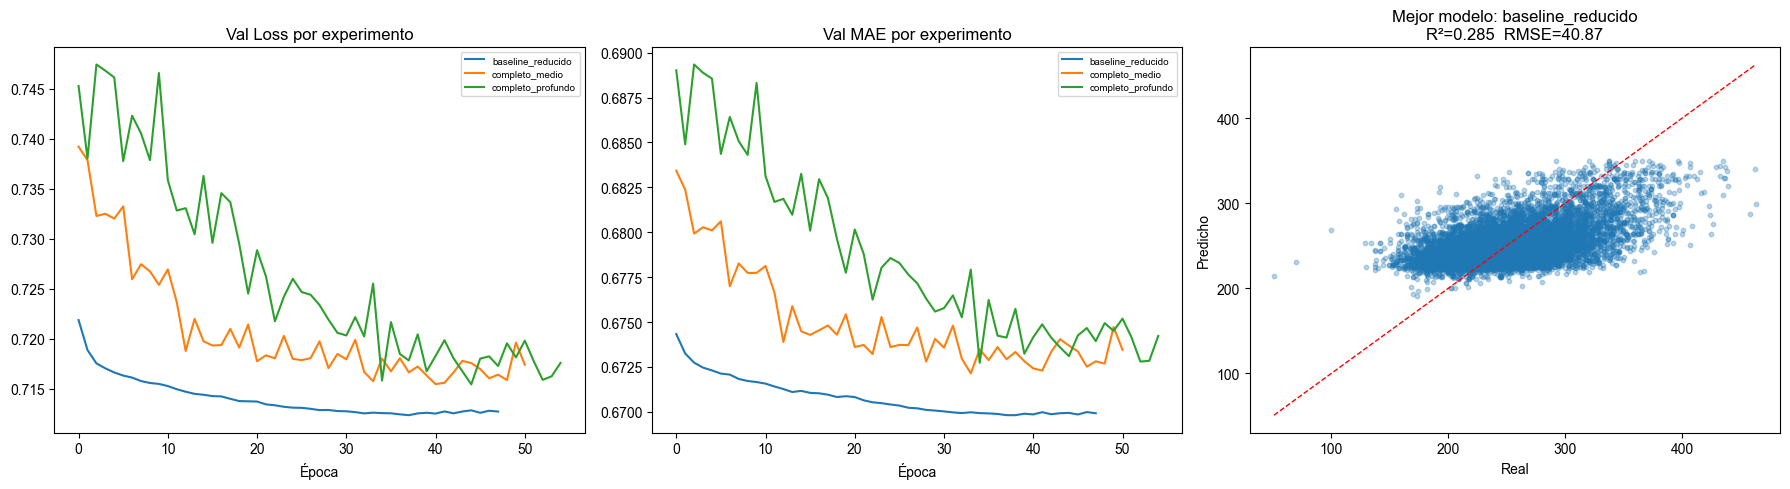

In [ ]:
tabla_p1 = PrettyTable()
tabla_p1.field_names = ["Experimento", "MAE", "RMSE", "R²"]
for nombre, res in resultados_p1.items():
    tabla_p1.add_row([
        nombre,
        f"{res['mae']:.2f}",
        f"{res['rmse']:.2f}",
        f"{res['r2']:.3f}"
    ])
print(tabla_p1)
 
mejor_p1 = max(resultados_p1, key=lambda n: resultados_p1[n]['r2'])
print(f"\nMejor modelo por R²: {mejor_p1}")
 
 
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
 
for nombre, res in resultados_p1.items():
    axes[0].plot(res['history'].history['val_loss'], label=nombre)
axes[0].set_title("Val Loss por experimento")
axes[0].set_xlabel("Época")
axes[0].legend(fontsize=7)
 
for nombre, res in resultados_p1.items():
    axes[1].plot(res['history'].history['val_mae'], label=nombre)
axes[1].set_title("Evolución del error de validación durante el entrenamiento")
axes[1].set_xlabel("Época")
axes[1].legend(fontsize=7)
 
y_te_best   = resultados_p1[mejor_p1]['y_te']
y_pred_best = resultados_p1[mejor_p1]['y_pred']
axes[2].scatter(y_te_best, y_pred_best, alpha=0.3, s=10)
axes[2].plot(
    [y_te_best.min(), y_te_best.max()],
    [y_te_best.min(), y_te_best.max()],
    'r--', lw=1
)
axes[2].set_xlabel("Real")
axes[2].set_ylabel("Predicho")
axes[2].set_title(
    f"Mejor modelo: {mejor_p1}\n"
    f"R²={resultados_p1[mejor_p1]['r2']:.3f}  RMSE={resultados_p1[mejor_p1]['rmse']:.2f}"
)
 
plt.tight_layout()
plt.show()
 
 

### 1.6 Guardar mejor modelo

In [10]:
print(f"Mejor modelo P1 por R²: {mejor_p1}")
shutil.copy(
    f"keras_models/model_p1_{mejor_p1}.keras",
    "../despliegue/models/model_p1.keras"
)
print(f"Guardado en ../despliegue/models/model_p1.keras")

Mejor modelo P1 por R²: baseline_reducido
Guardado en ../despliegue/models/model_p1.keras


In [27]:
import pickle

# Preparar datos con las 7 features del mejor modelo
X_temp = df_model_p1[FEATURES_REDUCIDOS_P1].values
imp_p1 = SimpleImputer(strategy='median').fit(X_temp)
scl_p1 = StandardScaler().fit(imp_p1.transform(X_temp))

# Scaler del target
_, _, _, _, _, _, scaler_y_best = preparar_datos_p1(FEATURES_REDUCIDOS_P1)

with open('../despliegue/models/scaler_p1.pkl', 'wb') as f:
    pickle.dump({
        'imputer': imp_p1, 
        'scaler_X': scl_p1, 
        'scaler_y': scaler_y_best
    }, f)

print("Scalers guardados correctamente")

Scalers guardados correctamente


## 2. Pregunta de negocio

### *¿Puede identificarse si un estudiante está en riesgo de obtener un puntaje global por debajo del umbral de bajo desempeño, según sus características socioeconómicas y escolares?*

Esta pregunta se responde con un **modelo de clasificación binaria**. La variable objetivo es:

$$\text{bajo\_rendimiento} = \begin{cases} 1 & \text{si } \texttt{punt\_global} < 220 \\ 0 & \text{en otro caso} \end{cases}$$

El umbral de 220 puntos delimita el tercio inferior de la distribución de puntajes en Caldas (~33.6% de los estudiantes), siendo operacionalmente accionable para el Ministerio: identifica una minoría prioritaria sin el severo desbalance de clases que produciría un umbral más bajo.

Se evalúan cinco configuraciones que responden dos preguntas de diseño: (1) ¿aportan los cuatro activos del hogar individualmente más que su índice resumen?, y (2) ¿qué profundidad y ancho captura mejor las interacciones entre features socioeconómicos y escolares?

### 2.1 Feature Engineering

In [11]:
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix,
                             ConfusionMatrixDisplay)
from sklearn.utils.class_weight import compute_class_weight

df_p2 = df.dropna(subset=['bajo_rendimiento']).copy()
TARGET_P2 = 'bajo_rendimiento'

FEATURES_REDUCIDOS = [
    'estrato_num', 'edu_madre_num', 'edu_padre_num',
    'indice_activos', 'es_privado', 'es_urbano', 'genero_num'
]
FEATURES_COMPLETOS = [
    'estrato_num', 'edu_madre_num', 'edu_padre_num',
    'indice_activos',
    'fami_tienecomputador', 'fami_tieneinternet',
    'fami_tieneautomovil', 'fami_tienelavadora',
    'es_privado', 'es_urbano', 'genero_num'
]

df_model_p2 = df_p2[FEATURES_COMPLETOS + [TARGET_P2]].dropna()
print(f"Shape: {df_model_p2.shape}")
print(f"Balance: {df_model_p2[TARGET_P2].value_counts(normalize=True).round(3).to_dict()}")

Shape: (43549, 12)
Balance: {0: 0.667, 1: 0.333}


### 2.2 Preprocesamiento

In [12]:
def preparar_datos(features):
    X = df_model_p2[features].values
    y = df_model_p2[TARGET_P2].values

    X = SimpleImputer(strategy='median').fit_transform(X)
    X = StandardScaler().fit_transform(X)

    X_tr, X_te, y_tr, y_te = train_test_split(
        X, y, test_size=0.2, random_state=SEED, stratify=y
    )
    X_tr, X_va, y_tr, y_va = train_test_split(
        X_tr, y_tr, test_size=0.2, random_state=SEED, stratify=y_tr
    )
    return X_tr, X_va, X_te, y_tr, y_va, y_te

X2_train, X2_val, X2_test, y2_train, y2_val, y2_test = preparar_datos(FEATURES_COMPLETOS)

clases = np.unique(y2_train)
pesos  = compute_class_weight('balanced', classes=clases, y=y2_train)
class_weight_p2 = dict(zip(clases, pesos))

print(f"Train: {X2_train.shape} | Val: {X2_val.shape} | Test: {X2_test.shape}")
print(f"Class weights: {class_weight_p2}")

Train: (27871, 11) | Val: (6968, 11) | Test: (8710, 11)
Class weights: {np.int64(0): np.float64(0.750148032513323), np.int64(1): np.float64(1.4994082203572197)}


### 2.3 Experimentos

In [13]:
experimentos_p2 = [
    {
        "nombre": "baseline_reducido",
        "features": FEATURES_REDUCIDOS,
        "capas": [16, 8],
        "dropout": 0.0,
        "learning_rate": 0.001,
        "epochs": 100,
        "batch_size": 64,
        "descripcion": "Sin assets individuales, sin regularizacion. Referencia minima."
    },
    {
        "nombre": "regularizado_reducido",
        "features": FEATURES_REDUCIDOS,
        "capas": [32, 16],
        "dropout": 0.3,
        "learning_rate": 0.001,
        "epochs": 100,
        "batch_size": 64,
        "descripcion": "Sin assets individuales, con dropout. Evalua regularizacion en features reducidos."
    },
    {
        "nombre": "completo_medio",
        "features": FEATURES_COMPLETOS,
        "capas": [64, 32],
        "dropout": 0.3,
        "learning_rate": 0.001,
        "epochs": 100,
        "batch_size": 64,
        "descripcion": "Con assets individuales. Evalua si aportan sobre el indice resumen."
    },
    {
        "nombre": "completo_profundo",
        "features": FEATURES_COMPLETOS,
        "capas": [128, 64, 32],
        "dropout": 0.3,
        "learning_rate": 0.0005,
        "epochs": 100,
        "batch_size": 64,
        "descripcion": "Mas capas para capturar interacciones entre activos y estrato."
    },
    {
        "nombre": "completo_ancho",
        "features": FEATURES_COMPLETOS,
        "capas": [256, 64],
        "dropout": 0.4,
        "learning_rate": 0.0005,
        "epochs": 100,
        "batch_size": 128,
        "descripcion": "Primera capa muy ancha para capturar combinaciones parciales de activos."
    }
]

### 2.4 Entrenamiento con MLflow

In [14]:
def construir_modelo(n_inputs, capas, dropout, learning_rate):
    seq = [layers.Input(shape=(n_inputs,))]
    for unidades in capas:
        seq.append(layers.Dense(unidades, activation='relu'))
        if dropout > 0:
            seq.append(layers.Dropout(dropout))
    seq.append(layers.Dense(1, activation='sigmoid'))

    m = tf.keras.Sequential(seq)
    m.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
        loss='binary_crossentropy',
        metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
    )
    return m

mlflow.set_experiment("P2_clasificacion_riesgo")

resultados_p2 = {}

for config in experimentos_p2:
    nombre = config["nombre"]

    X_tr, X_va, X_te, y_tr, y_va, y_te = preparar_datos(config["features"])

    with mlflow.start_run(run_name=nombre):
        mlflow.log_param("capas",         config["capas"])
        mlflow.log_param("dropout",       config["dropout"])
        mlflow.log_param("learning_rate", config["learning_rate"])
        mlflow.log_param("batch_size",    config["batch_size"])
        mlflow.log_param("n_features",    len(config["features"]))
        mlflow.log_param("descripcion",   config["descripcion"])

        modelo = construir_modelo(
            n_inputs=len(config["features"]),
            capas=config["capas"],
            dropout=config["dropout"],
            learning_rate=config["learning_rate"]
        )

        early_stop_p2 = callbacks.EarlyStopping(
            monitor='val_auc', patience=10,
            restore_best_weights=True, mode='max'
        )

        history = modelo.fit(
            X_tr, y_tr,
            validation_data=(X_va, y_va),
            epochs=config["epochs"],
            batch_size=config["batch_size"],
            class_weight=class_weight_p2,
            callbacks=[early_stop_p2],
            verbose=0
        )

        y_prob = modelo.predict(X_te, verbose=0).flatten()
        y_pred = (y_prob >= 0.5).astype(int)

        acc  = accuracy_score(y_te, y_pred)
        prec = precision_score(y_te, y_pred)
        rec  = recall_score(y_te, y_pred)
        f1   = f1_score(y_te, y_pred)
        auc  = roc_auc_score(y_te, y_prob)

        mlflow.log_metric("accuracy",  acc)
        mlflow.log_metric("precision", prec)
        mlflow.log_metric("recall",    rec)
        mlflow.log_metric("f1",        f1)
        mlflow.log_metric("auc_roc",   auc)
        mlflow.log_metric("epochs_reales", len(history.history['loss']))

        modelo.save(f"keras_models/model_p2_{nombre}.keras")

        resultados_p2[nombre] = {
            "acc": acc, "prec": prec, "rec": rec, "f1": f1, "auc": auc,
            "history": history, "y_prob": y_prob, "y_pred": y_pred, "y_te": y_te
        }
        print(f"[{nombre}]  Acc={acc:.3f}  Prec={prec:.3f}  Rec={rec:.3f}  F1={f1:.3f}  AUC={auc:.3f}")

[baseline_reducido]  Acc=0.633  Prec=0.469  Rec=0.757  F1=0.579  AUC=0.716
[regularizado_reducido]  Acc=0.628  Prec=0.464  Rec=0.753  F1=0.574  AUC=0.717
[completo_medio]  Acc=0.640  Prec=0.474  Rec=0.733  F1=0.576  AUC=0.718
[completo_profundo]  Acc=0.643  Prec=0.477  Rec=0.737  F1=0.579  AUC=0.718
[completo_ancho]  Acc=0.642  Prec=0.476  Rec=0.735  F1=0.578  AUC=0.718


### 2.5 Comparación de modelos

In [15]:
tabla_p2 = PrettyTable()
tabla_p2.field_names = ["Experimento", "Accuracy", "Precision", "Recall", "F1", "AUC-ROC"]
for nombre, res in resultados_p2.items():
    tabla_p2.add_row([
        nombre,
        f"{res['acc']:.3f}", f"{res['prec']:.3f}",
        f"{res['rec']:.3f}", f"{res['f1']:.3f}", f"{res['auc']:.3f}"
    ])
print(tabla_p2)

mejor_p2 = max(resultados_p2, key=lambda n: resultados_p2[n]['f1'])
print(f"\nMejor modelo por F1: {mejor_p2}")

+-----------------------+----------+-----------+--------+-------+---------+
|      Experimento      | Accuracy | Precision | Recall |   F1  | AUC-ROC |
+-----------------------+----------+-----------+--------+-------+---------+
|   baseline_reducido   |  0.633   |   0.469   | 0.757  | 0.579 |  0.716  |
| regularizado_reducido |  0.628   |   0.464   | 0.753  | 0.574 |  0.717  |
|     completo_medio    |  0.640   |   0.474   | 0.733  | 0.576 |  0.718  |
|   completo_profundo   |  0.643   |   0.477   | 0.737  | 0.579 |  0.718  |
|     completo_ancho    |  0.642   |   0.476   | 0.735  | 0.578 |  0.718  |
+-----------------------+----------+-----------+--------+-------+---------+

Mejor modelo por F1: completo_profundo


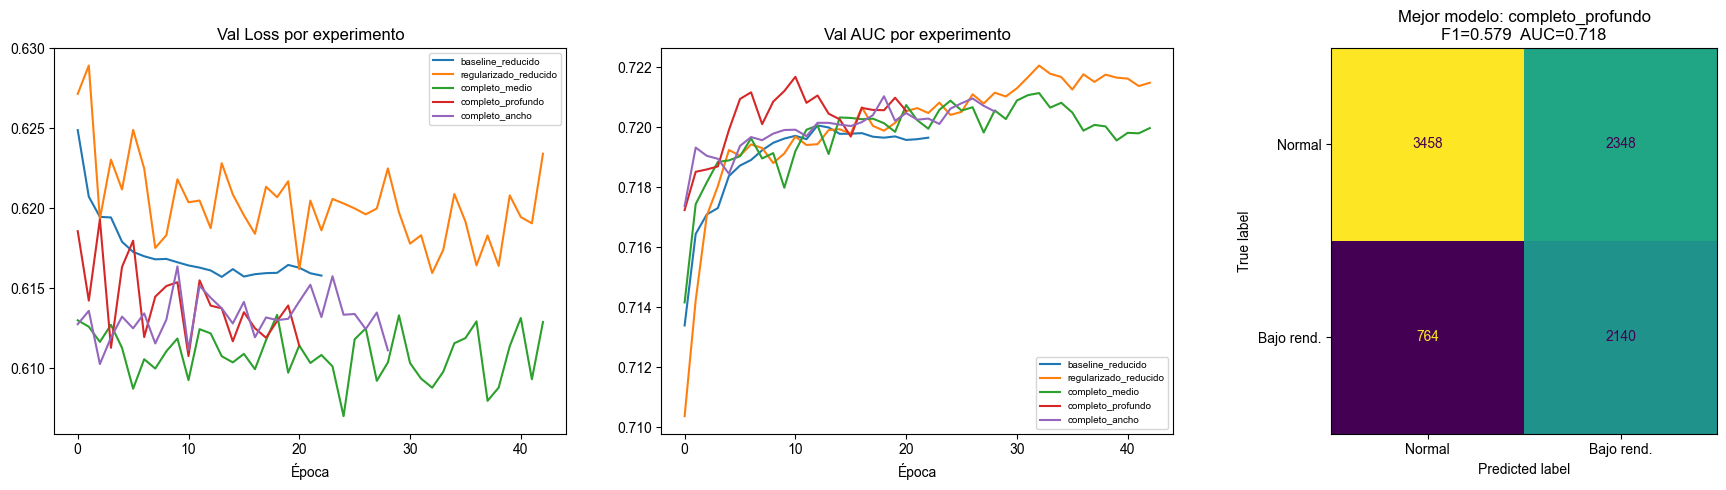

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for nombre, res in resultados_p2.items():
    axes[0].plot(res['history'].history['val_loss'], label=nombre)
axes[0].set_title("Val Loss por experimento")
axes[0].set_xlabel("Época")
axes[0].legend(fontsize=7)

for nombre, res in resultados_p2.items():
    axes[1].plot(res['history'].history['val_auc'], label=nombre)
axes[1].set_title("Val AUC por experimento")
axes[1].set_xlabel("Época")
axes[1].legend(fontsize=7)

cm = confusion_matrix(resultados_p2[mejor_p2]['y_te'], resultados_p2[mejor_p2]['y_pred'])
ConfusionMatrixDisplay(cm, display_labels=['Normal', 'Bajo rend.']).plot(ax=axes[2], colorbar=False)
axes[2].set_title(f"Mejor modelo: {mejor_p2}\nF1={resultados_p2[mejor_p2]['f1']:.3f}  AUC={resultados_p2[mejor_p2]['auc']:.3f}")

plt.tight_layout()
plt.show()

### 2.6 Reporte de clasificación del mejor modelo

In [17]:
from sklearn.metrics import classification_report

print(
    classification_report(
        resultados_p2[mejor_p2]['y_te'],
        resultados_p2[mejor_p2]['y_pred'],
        target_names=['Normal', 'Bajo rendimiento'],
        zero_division=0
    )
)

                  precision    recall  f1-score   support

          Normal       0.82      0.60      0.69      5806
Bajo rendimiento       0.48      0.74      0.58      2904

        accuracy                           0.64      8710
       macro avg       0.65      0.67      0.63      8710
    weighted avg       0.70      0.64      0.65      8710



### 2.7 Guardar mejor modelo

In [18]:
print(f"Mejor modelo P2 por F1: {mejor_p2}")
shutil.copy(
    f"keras_models/model_p2_{mejor_p2}.keras",
    "../despliegue/models/model_p2.keras"
)
print(f"Guardado en ../despliegue/models/model_p2.keras")

Mejor modelo P2 por F1: completo_profundo
Guardado en ../despliegue/models/model_p2.keras


## 3. Pregunta de negocio

### *¿Puede predecirse el nivel de desempeño en inglés de un estudiante (A−, A1, A2, B1, B+) a partir de su perfil académico, socioeconómico y de género?*

Esta pregunta se responde con un modelo de clasificación multiclase, ya que la variable objetivo es categórica:


Y = desemp_ingles \in {A-, A1, A2, B1, B+}


El objetivo es predecir el nivel de desempeño en inglés de un estudiante de Caldas a partir de su perfil académico, socioeconómico y de género. Esta predicción puede apoyar la identificación de perfiles con bajo desempeño esperado y orientar estrategias de refuerzo en competencias de inglés.


### 3.1 Feature Engineering

In [19]:
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay, classification_report
)
from sklearn.utils.class_weight import compute_class_weight

df_p3 = df.dropna(subset=['desemp_ingles']).copy()
TARGET_P3 = 'desemp_ingles'

# Mantener únicamente las categorías esperadas
niveles_ingles = ['A-', 'A1', 'A2', 'B1', 'B+']
df_p3 = df_p3[df_p3[TARGET_P3].isin(niveles_ingles)].copy()

# Codificar target multiclase
label_encoder_p3 = LabelEncoder()
df_p3['desemp_ingles_encoded'] = label_encoder_p3.fit_transform(df_p3[TARGET_P3])

TARGET_P3_ENCODED = 'desemp_ingles_encoded'

FEATURES_REDUCIDOS_P3 = [
    'punt_matematicas',
    'punt_lectura_critica',
    'punt_c_naturales',
    'punt_sociales_ciudadanas',
    'estrato_num',
    'edu_madre_num',
    'edu_padre_num',
    'indice_activos',
    'genero_num'
]

FEATURES_COMPLETOS_P3 = [
    'punt_matematicas',
    'punt_lectura_critica',
    'punt_c_naturales',
    'punt_sociales_ciudadanas',
    'estrato_num',
    'edu_madre_num',
    'edu_padre_num',
    'indice_activos',
    'fami_tienecomputador',
    'fami_tieneinternet',
    'fami_tieneautomovil',
    'fami_tienelavadora',
    'es_privado',
    'es_urbano',
    'cole_bilingue',
    'genero_num'
]

df_model_p3 = df_p3[FEATURES_COMPLETOS_P3 + [TARGET_P3, TARGET_P3_ENCODED]].dropna().copy()

print(f"Shape: {df_model_p3.shape}")
print("Clases:", list(label_encoder_p3.classes_))
print("Distribución del target:")
print(df_model_p3[TARGET_P3].value_counts(normalize=True).round(3))

Shape: (39353, 18)
Clases: ['A-', 'A1', 'A2', 'B+', 'B1']
Distribución del target:
desemp_ingles
A-    0.461
A1    0.336
A2    0.126
B1    0.058
B+    0.019
Name: proportion, dtype: float64


### 3.2 Preprocesamiento

In [20]:
def preparar_datos_p3(features):
    X = df_model_p3[features].values
    y = df_model_p3[TARGET_P3_ENCODED].values

    X = SimpleImputer(strategy='median').fit_transform(X)
    X = StandardScaler().fit_transform(X)

    X_tr, X_te, y_tr, y_te = train_test_split(
        X, y,
        test_size=0.2,
        random_state=SEED,
        stratify=y
    )

    X_tr, X_va, y_tr, y_va = train_test_split(
        X_tr, y_tr,
        test_size=0.2,
        random_state=SEED,
        stratify=y_tr
    )

    return X_tr, X_va, X_te, y_tr, y_va, y_te

X3_train, X3_val, X3_test, y3_train, y3_val, y3_test = preparar_datos_p3(FEATURES_COMPLETOS_P3)

clases_p3 = np.unique(y3_train)
pesos_p3 = compute_class_weight(
    class_weight='balanced',
    classes=clases_p3,
    y=y3_train
)

class_weight_p3 = dict(zip(clases_p3, pesos_p3))

print(f"Train: {X3_train.shape} | Val: {X3_val.shape} | Test: {X3_test.shape}")
print(f"Class weights: {class_weight_p3}")

Train: (25185, 16) | Val: (6297, 16) | Test: (7871, 16)
Class weights: {np.int64(0): np.float64(0.43407445708376424), np.int64(1): np.float64(0.5956717123935666), np.int64(2): np.float64(1.5834643193964162), np.int64(3): np.float64(10.279591836734694), np.int64(4): np.float64(3.4642365887207704)}


### 3.3 Experimentos

In [21]:
experimentos_p3 = [
    {
        "nombre": "baseline_reducido",
        "features": FEATURES_REDUCIDOS_P3,
        "capas": [32, 16],
        "dropout": 0.0,
        "learning_rate": 0.001,
        "epochs": 100,
        "batch_size": 64,
        "descripcion": "Features academicos, socioeconomicos y genero. Sin regularizacion."
    },
    {
        "nombre": "regularizado_reducido",
        "features": FEATURES_REDUCIDOS_P3,
        "capas": [64, 32],
        "dropout": 0.3,
        "learning_rate": 0.001,
        "epochs": 100,
        "batch_size": 64,
        "descripcion": "Features reducidos con dropout para controlar sobreajuste."
    },
    {
        "nombre": "completo_medio",
        "features": FEATURES_COMPLETOS_P3,
        "capas": [64, 32],
        "dropout": 0.3,
        "learning_rate": 0.001,
        "epochs": 100,
        "batch_size": 64,
        "descripcion": "Incluye activos individuales y variables escolares."
    },
    {
        "nombre": "completo_profundo",
        "features": FEATURES_COMPLETOS_P3,
        "capas": [128, 64, 32],
        "dropout": 0.3,
        "learning_rate": 0.0005,
        "epochs": 100,
        "batch_size": 64,
        "descripcion": "Mayor profundidad para capturar interacciones entre rendimiento academico y contexto."
    },
    {
        "nombre": "completo_ancho",
        "features": FEATURES_COMPLETOS_P3,
        "capas": [256, 128],
        "dropout": 0.4,
        "learning_rate": 0.0005,
        "epochs": 100,
        "batch_size": 128,
        "descripcion": "Arquitectura mas ancha para capturar combinaciones no lineales entre variables."
    }
]

### 3.4 Entrenamiento con MLflow

In [22]:
def construir_modelo_p3(n_inputs, n_clases, capas, dropout, learning_rate):
    seq = [layers.Input(shape=(n_inputs,))]

    for unidades in capas:
        seq.append(layers.Dense(unidades, activation='relu'))
        if dropout > 0:
            seq.append(layers.Dropout(dropout))

    seq.append(layers.Dense(n_clases, activation='softmax'))

    m = tf.keras.Sequential(seq)

    m.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    return m


mlflow.set_experiment("P3_clasificacion_desempeno_ingles")

resultados_p3 = {}

for config in experimentos_p3:
    nombre = config["nombre"]

    X_tr, X_va, X_te, y_tr, y_va, y_te = preparar_datos_p3(config["features"])

    clases_run = np.unique(y_tr)
    pesos_run = compute_class_weight(
        class_weight='balanced',
        classes=clases_run,
        y=y_tr
    )
    class_weight_run = dict(zip(clases_run, pesos_run))

    with mlflow.start_run(run_name=nombre):
        mlflow.log_param("capas", config["capas"])
        mlflow.log_param("dropout", config["dropout"])
        mlflow.log_param("learning_rate", config["learning_rate"])
        mlflow.log_param("batch_size", config["batch_size"])
        mlflow.log_param("n_features", len(config["features"]))
        mlflow.log_param("features", config["features"])
        mlflow.log_param("descripcion", config["descripcion"])

        modelo = construir_modelo_p3(
            n_inputs=len(config["features"]),
            n_clases=len(label_encoder_p3.classes_),
            capas=config["capas"],
            dropout=config["dropout"],
            learning_rate=config["learning_rate"]
        )

        early_stop_p3 = callbacks.EarlyStopping(
            monitor='val_accuracy',
            patience=10,
            restore_best_weights=True,
            mode='max'
        )

        history = modelo.fit(
            X_tr, y_tr,
            validation_data=(X_va, y_va),
            epochs=config["epochs"],
            batch_size=config["batch_size"],
            class_weight=class_weight_run,
            callbacks=[early_stop_p3],
            verbose=0
        )

        y_prob = modelo.predict(X_te, verbose=0)
        y_pred = np.argmax(y_prob, axis=1)

        acc = accuracy_score(y_te, y_pred)
        prec_macro = precision_score(y_te, y_pred, average='macro', zero_division=0)
        rec_macro = recall_score(y_te, y_pred, average='macro', zero_division=0)
        f1_macro = f1_score(y_te, y_pred, average='macro', zero_division=0)

        mlflow.log_metric("accuracy", acc)
        mlflow.log_metric("precision_macro", prec_macro)
        mlflow.log_metric("recall_macro", rec_macro)
        mlflow.log_metric("f1_macro", f1_macro)
        mlflow.log_metric("epochs_reales", len(history.history['loss']))

        modelo.save(f"keras_models/model_p3_{nombre}.keras")

        resultados_p3[nombre] = {
            "acc": acc,
            "prec_macro": prec_macro,
            "rec_macro": rec_macro,
            "f1_macro": f1_macro,
            "history": history,
            "y_prob": y_prob,
            "y_pred": y_pred,
            "y_te": y_te
        }

        print(
            f"[{nombre}] "
            f"Acc={acc:.3f} "
            f"Prec_macro={prec_macro:.3f} "
            f"Rec_macro={rec_macro:.3f} "
            f"F1_macro={f1_macro:.3f}"
        )

[baseline_reducido] Acc=0.532 Prec_macro=0.426 Rec_macro=0.520 F1_macro=0.454
[regularizado_reducido] Acc=0.538 Prec_macro=0.421 Rec_macro=0.519 F1_macro=0.449
[completo_medio] Acc=0.543 Prec_macro=0.438 Rec_macro=0.535 F1_macro=0.467
[completo_profundo] Acc=0.544 Prec_macro=0.443 Rec_macro=0.536 F1_macro=0.473
[completo_ancho] Acc=0.557 Prec_macro=0.442 Rec_macro=0.537 F1_macro=0.470


### 3.5 Comparación de modelos

In [23]:
tabla_p3 = PrettyTable()
tabla_p3.field_names = [
    "Experimento",
    "Accuracy",
    "Precision macro",
    "Recall macro",
    "F1 macro"
]

for nombre, res in resultados_p3.items():
    tabla_p3.add_row([
        nombre,
        f"{res['acc']:.3f}",
        f"{res['prec_macro']:.3f}",
        f"{res['rec_macro']:.3f}",
        f"{res['f1_macro']:.3f}"
    ])

print(tabla_p3)

mejor_p3 = max(resultados_p3, key=lambda n: resultados_p3[n]['f1_macro'])
print(f"\nMejor modelo por F1 macro: {mejor_p3}")

+-----------------------+----------+-----------------+--------------+----------+
|      Experimento      | Accuracy | Precision macro | Recall macro | F1 macro |
+-----------------------+----------+-----------------+--------------+----------+
|   baseline_reducido   |  0.532   |      0.426      |    0.520     |  0.454   |
| regularizado_reducido |  0.538   |      0.421      |    0.519     |  0.449   |
|     completo_medio    |  0.543   |      0.438      |    0.535     |  0.467   |
|   completo_profundo   |  0.544   |      0.443      |    0.536     |  0.473   |
|     completo_ancho    |  0.557   |      0.442      |    0.537     |  0.470   |
+-----------------------+----------+-----------------+--------------+----------+

Mejor modelo por F1 macro: completo_profundo


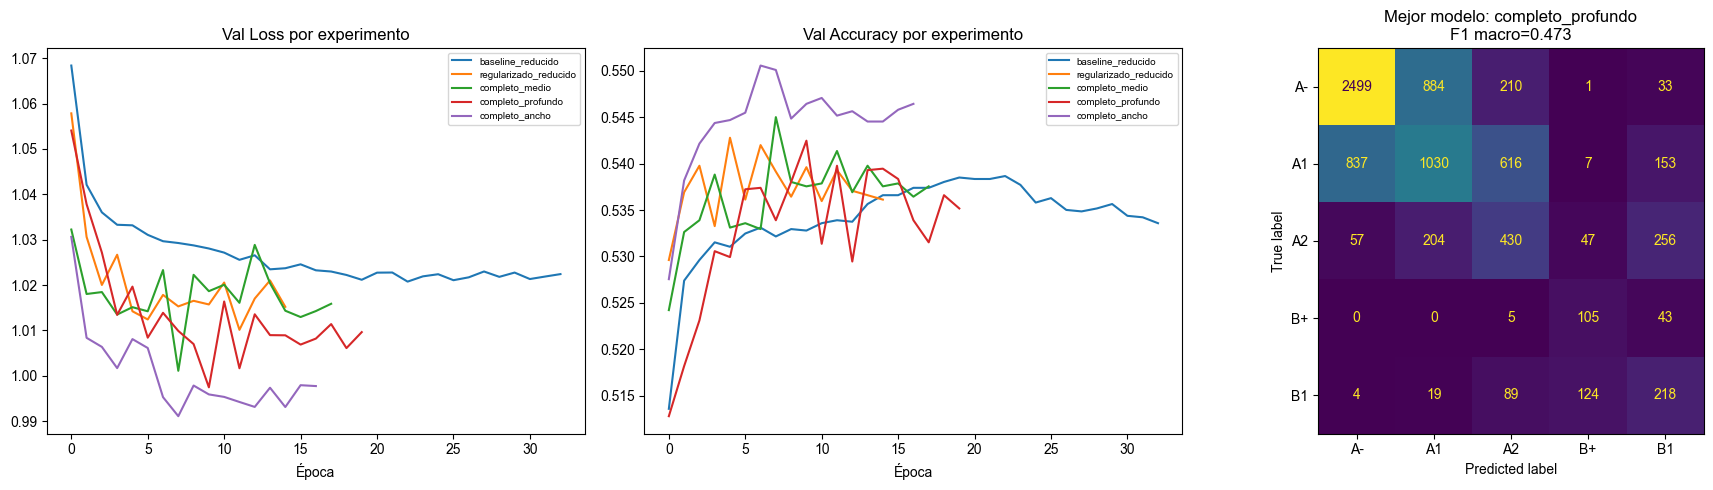

In [24]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for nombre, res in resultados_p3.items():
    axes[0].plot(res['history'].history['val_loss'], label=nombre)

axes[0].set_title("Val Loss por experimento")
axes[0].set_xlabel("Época")
axes[0].legend(fontsize=7)

for nombre, res in resultados_p3.items():
    axes[1].plot(res['history'].history['val_accuracy'], label=nombre)

axes[1].set_title("Val Accuracy por experimento")
axes[1].set_xlabel("Época")
axes[1].legend(fontsize=7)

cm_p3 = confusion_matrix(
    resultados_p3[mejor_p3]['y_te'],
    resultados_p3[mejor_p3]['y_pred']
)

ConfusionMatrixDisplay(
    cm_p3,
    display_labels=label_encoder_p3.classes_
).plot(ax=axes[2], colorbar=False)

axes[2].set_title(
    f"Mejor modelo: {mejor_p3}\n"
    f"F1 macro={resultados_p3[mejor_p3]['f1_macro']:.3f}"
)

plt.tight_layout()
plt.show()

### 3.6 Reporte de clasificación del mejor modelo

In [25]:
print(
    classification_report(
        resultados_p3[mejor_p3]['y_te'],
        resultados_p3[mejor_p3]['y_pred'],
        target_names=label_encoder_p3.classes_,
        zero_division=0
    )
)

              precision    recall  f1-score   support

          A-       0.74      0.69      0.71      3627
          A1       0.48      0.39      0.43      2643
          A2       0.32      0.43      0.37       994
          B+       0.37      0.69      0.48       153
          B1       0.31      0.48      0.38       454

    accuracy                           0.54      7871
   macro avg       0.44      0.54      0.47      7871
weighted avg       0.57      0.54      0.55      7871



### 3.7 Guardar mejor modelo

In [26]:
print(f"Mejor modelo P3 por F1 macro: {mejor_p3}")
shutil.copy(
    f"keras_models/model_p3_{mejor_p3}.keras",
    "../despliegue/models/model_p3.keras"
)
print(f"Guardado en ../despliegue/models/model_p3.keras")

Mejor modelo P3 por F1 macro: completo_profundo
Guardado en ../despliegue/models/model_p3.keras
